In [2]:
import pandas as pd
import re

def clean_text(text):
    # Added str() to prevent errors if an article is completely blank
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def main():
    print("Loading raw datasets into Colab...")
    # Added lineterminator='\n' to fix the EOF parsing error
    fake_df = pd.read_csv('Fake.csv', lineterminator='\n')
    true_df = pd.read_csv('True.csv', lineterminator='\n')

    true_df['label'] = 1
    fake_df['label'] = 0

    print("Merging datasets...")
    combined_df = pd.concat([true_df, fake_df], ignore_index=True)

    print("Cleaning text data... (This may take a minute or two)")
    combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

    # Saving directly to Colab's main folder
    output_path = 'cleaned_news_dataset.csv'
    combined_df.to_csv(output_path, index=False)

    print(f"Success! Cleaned dataset saved as: {output_path}")

main()

Loading raw datasets into Colab...
Merging datasets...
Cleaning text data... (This may take a minute or two)
Success! Cleaned dataset saved as: cleaned_news_dataset.csv


Load and Split the Clean Data

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Loading clean dataset for training...")
# Loading directly from Colab's main folder
df = pd.read_csv('cleaned_news_dataset.csv')

# Drop any rows where the cleaning process left empty strings
df = df.dropna(subset=['cleaned_text'])

# Define X (Features) and y (Target)
X = df['cleaned_text']
y = df['label']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Loading clean dataset for training...
Training samples: 35346
Testing samples: 8837


Train and Evaluate the Naive Bayes Model

1. Vectorizing text using TF-IDF...
2. Training Multinomial Naive Bayes model...
3. Generating Evaluation Metrics...

--- Naive Bayes Evaluation ---
Accuracy:  0.9444

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Fake (0)       0.95      0.94      0.95      4516
    Real (1)       0.94      0.94      0.94      4321

    accuracy                           0.94      8837
   macro avg       0.94      0.94      0.94      8837
weighted avg       0.94      0.94      0.94      8837



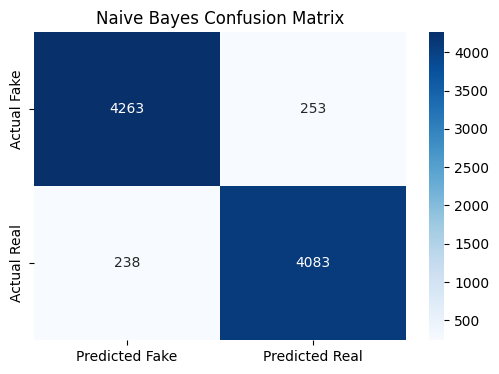

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Vectorizing text using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("2. Training Multinomial Naive Bayes model...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("3. Generating Evaluation Metrics...\n")
y_pred = nb_model.predict(X_test_tfidf)

print("--- Naive Bayes Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Naive Bayes Confusion Matrix')
plt.show()